In [1]:
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.constants import c as c_light
from scipy.constants import mu_0 as mu_0
from tqdm import tqdm

sys.path.append("../")

from wakis.gridFIT3D import GridFIT3D
from wakis.solverFIT3D import SolverFIT3D
from wakis.sources import Pulse


## Simulation Domain

In [2]:
Nx = 200
Ny = 20
Nz = 20

xmin, xmax, ymin, ymax, zmin, zmax = -0.125, 0.375, -0.025, 0.025, -0.025, 0.025
grid = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz)
Nt = 530
dt = 2.5e-12

bc_low = ["cpml", "periodic", "pec"]
bc_high = ["cpml", "periodic", "pec"]

Generating grid with 80000 mesh cells...
Importing STL solids...
Total grid initialization time: 0.009310483932495117 s


In [ ]:
E_pml = []

# set solver
solver = SolverFIT3D(grid, bc_low=bc_low, bc_high=bc_high, dt=dt, kappa_max=5, alpha_max=0.05, pml_exp=4, sigma_factor=1.0, n_pml=10) # Parameters to tune CPML: kappa_max, alpha_max, pml_exp, sigma_factor, n_pml

print("Time step:", solver.dt)

# set source
source = Pulse(
    field="Ez",
    xs=50,
    ys = slice(0, Ny),
    zs=slice(0, Nz),
    shape="harris",
    L = 0.15,
)

for n in tqdm(range(Nt)):
    source.update(solver, n * solver.dt)
    solver.one_step()
    E_pml.append((solver.E[20, Ny//2, Nz//2, 'z'].copy()))

Initializing Electromagnetic solver...
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
Filling CPML parameters...
Calculating maximal stable timestep...
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 0.18987655639648438 s
Time step: 2.5e-12


100%|██████████| 530/530 [00:03<00:00, 142.37it/s]


## Reference

In [4]:
Nx = 300
xmin= -0.375
gridRef = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz)

E_ref = []

# set solver
solverRef = SolverFIT3D(gridRef, bc_low=bc_low, bc_high=bc_high, dt=dt, n_pml=0)
print("Time step:", solverRef.dt)

# set source
sourceRef = Pulse(
    field="Ez",
    xs=150,
    ys = slice(0, Ny),
    zs=slice(0, Nz),
    shape="harris",
    L = 0.15,
)


# ------------ Time loop ----------------

for n in tqdm(range(Nt)):
    sourceRef.update(solverRef, n * solverRef.dt)
    solverRef.one_step()
    E_ref.append((solverRef.E[120, Ny//2, Nz//2, 'z'].copy()))


/home/anhuber/cernbox/WakisDev/wakis/notebooks/../wakis/boundaries.py:369: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_max = -self.sigma_factor * (self.pml_exp + 1) * np.log(R0) / (2 * L * eta_0)
/home/anhuber/cernbox/WakisDev/wakis/notebooks/../wakis/boundaries.py:432: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_max = -self.sigma_factor * (self.pml_exp + 1) * np.log(R0) / (2 * L * eta_0)


Generating grid with 120000 mesh cells...
Importing STL solids...
Total grid initialization time: 0.006436586380004883 s
Initializing Electromagnetic solver...
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
Filling CPML parameters...
Calculating maximal stable timestep...
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 0.2607600688934326 s
Time step: 2.5e-12


100%|██████████| 530/530 [00:05<00:00, 92.87it/s]


## Analysis

In [5]:
f = np.fft.fftfreq(Nt, dt)
mask = (f >= 0)
SRef = np.fft.fft(E_ref)
SPML = np.fft.fft(E_pml)
SDiff = SPML - SRef
Sreflec = (np.abs(SDiff)/np.abs(SRef))**2

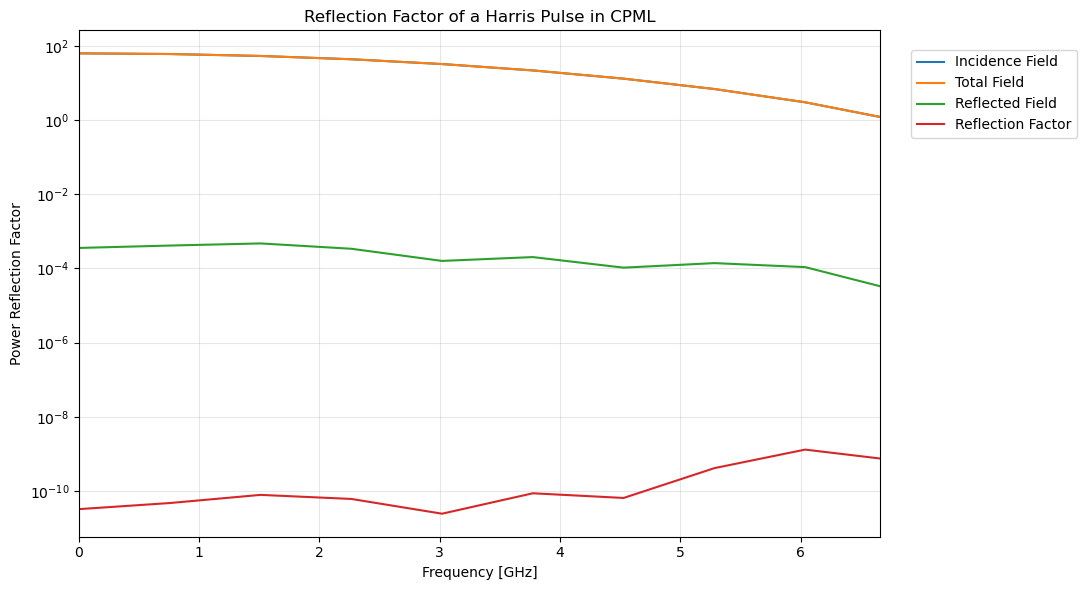

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(f[mask]*1e-9, np.abs(SRef[mask]), label = "Incidence Field")
ax.plot(f[mask]*1e-9, np.abs(SPML[mask]), label = "Total Field")
ax.plot(f[mask]*1e-9, np.abs(SDiff[mask]), label = "Reflected Field")
ax.plot(f[mask]*1e-9, np.abs(Sreflec[mask]), label = "Reflection Factor")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Power Reflection Factor")
ax.set_xlim(0, 6.66)
ax.grid(True, which='both', axis='y', alpha=0.3)
ax.grid(True, which='both', axis='x', alpha=0.3)
ax.set_yscale('log')
ax.set_title("Reflection Factor of a Harris Pulse in CPML")

fig.legend(loc='upper left', bbox_to_anchor=(1.01, 0.92))
fig.tight_layout()
plt.show()